# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
df = pd.read_csv('data/AviationData_clean.csv', low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (19662, 34)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,total_aboard,fatal_serious_fraction,is_destroyed,make_model
0,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,0.0,0.0,IMC,Cruise,Probable Cause,02-05-2011,2.0,1.000000,1,Piper PA-28-140
1,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,...,0.0,4.0,VMC,Standing,Probable Cause,17-10-2016,5.0,0.200000,0,De Havilland DHC-6
2,20001214X44100,Accident,DCA83AA036,1983-08-21,"SILVANA, WA",United States,NaN,NaN,S88,NaN,...,0.0,13.0,VMC,Other,Probable Cause,17-10-2016,26.0,0.500000,1,"Lockheed LEARSTAR, L-18-56"
3,20001214X44944,Accident,NYC84LA015,1983-10-28,"MIDDLETOWN, PA",United States,NaN,NaN,NaN,NaN,...,0.0,29.0,VMC,Climb,Probable Cause,09-12-2011,30.0,0.033333,0,Short Brothers SD3-30
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,0.0,1.0,VMC,Climb,Probable Cause,05-05-2011,1.0,0.000000,0,Beech C35


In [4]:
print("Key columns dtypes:")
print(df[['fatal_serious_fraction', 'is_destroyed', 'total_aboard',
          'Make', 'make_model', 'Number.of.Engines',
          'Weather.Condition', 'Engine.Type',
          'Broad.phase.of.flight', 'Purpose.of.flight']].dtypes)
print("\nfatal_serious_fraction stats:")
print(df['fatal_serious_fraction'].describe())

Key columns dtypes:
fatal_serious_fraction    float64
is_destroyed                int64
total_aboard              float64
Make                       object
make_model                 object
Number.of.Engines         float64
Weather.Condition          object
Engine.Type                object
Broad.phase.of.flight      object
Purpose.of.flight          object
dtype: object

fatal_serious_fraction stats:
count    19662.000000
mean         0.295899
std          0.436685
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: fatal_serious_fraction, dtype: float64


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [5]:
# Split into small (<=20) and large (>20) based on total_aboard
df_small = df[df['total_aboard'] <= 20].copy()
df_large = df[df['total_aboard'] > 20].copy()

print(f"Small aircraft records: {len(df_small)}")
print(f"Large aircraft records: {len(df_large)}")
print(f"\nSmall - mean fatal_serious_fraction: {df_small['fatal_serious_fraction'].mean():.4f}")
print(f"Large - mean fatal_serious_fraction: {df_large['fatal_serious_fraction'].mean():.4f}")

Small aircraft records: 19085
Large aircraft records: 577

Small - mean fatal_serious_fraction: 0.3015
Large - mean fatal_serious_fraction: 0.1103


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [12]:
# Compute mean fatal_serious_fraction per make with minimum count filter (n >= 50)
def top_safe_makes(subset, n_top=15, min_count=50):
    stats = (subset.groupby('Make')
             .agg(mean_fsf=('fatal_serious_fraction', 'mean'),
                  count=('fatal_serious_fraction', 'count'))
             .query(f'count >= {min_count}')
             .sort_values('mean_fsf')
             .head(n_top))
    return stats

small_makes = top_safe_makes(df_small, n_top=15)
large_makes = top_safe_makes(df_large, n_top=15)

print("Top 15 safest makes (small aircraft):")
print(small_makes)
print("\nTop 15 safest makes (large aircraft):")
print(large_makes)

Top 15 safest makes (small aircraft):
                                mean_fsf  count
Make                                           
Maule                           0.073944     71
Bellanca                        0.139344     61
AVIAT AIRCRAFT INC              0.145833     72
Aeronca                         0.147059     51
Cessna                          0.176456   2254
Air Tractor                     0.200855    117
Piper                           0.201533   1174
GRUMMAN ACFT ENG COR-SCHWEIZER  0.206897     58
MAULE                           0.209606    144
BOEING                          0.212008    150
ROCKWELL INTERNATIONAL          0.221667     50
DEHAVILLAND                     0.228263     90
DIAMOND AIRCRAFT IND INC        0.229167     72
STINSON                         0.243590     91
AERONCA                         0.252796    149

Top 15 safest makes (large aircraft):
        mean_fsf  count
Make                   
BOEING  0.093856    218
Boeing  0.114382     79
AIRBUS  0.1

C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\2822434827.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=small_makes.reset_index(), x='mean_fsf', y='Make',
C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\2822434827.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=large_makes.reset_index(), x='mean_fsf', y='Make',


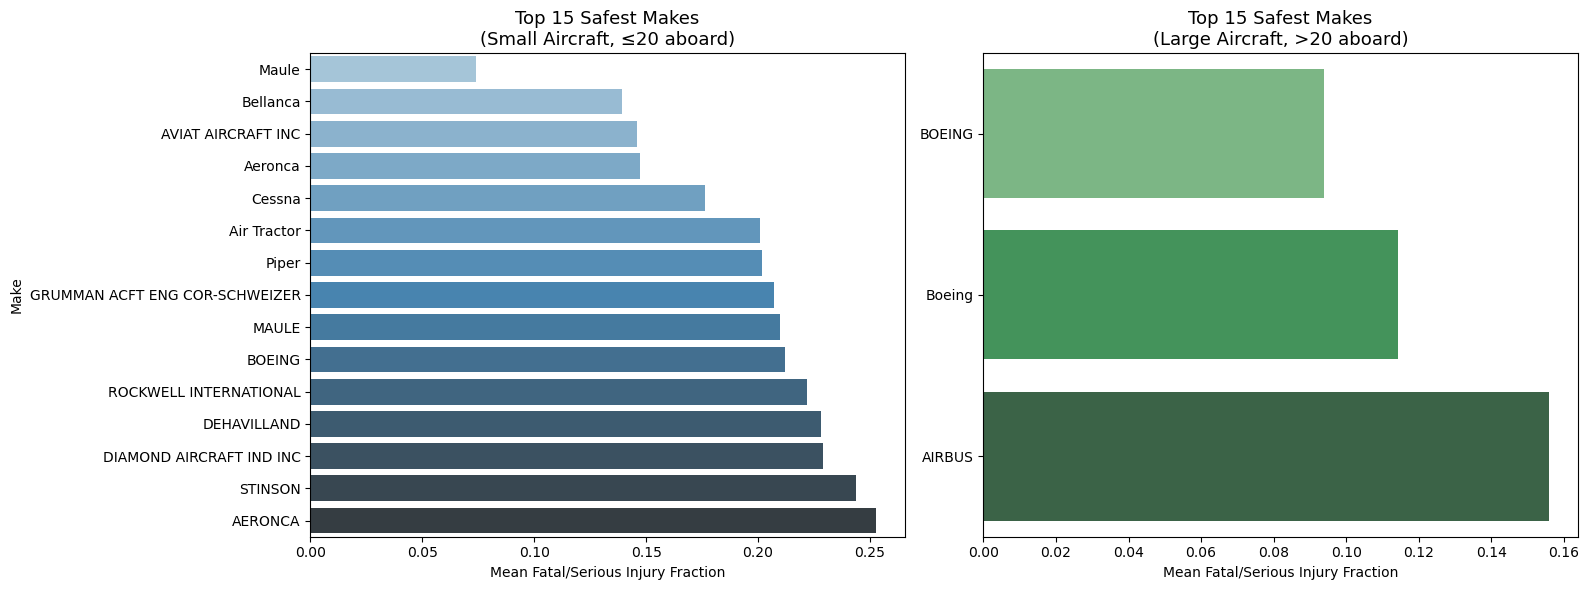

Figure saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Small aircraft
sns.barplot(data=small_makes.reset_index(), x='mean_fsf', y='Make',
            ax=axes[0], palette='Blues_d', orient='h')
axes[0].set_title('Top 15 Safest Makes\n(Small Aircraft, ≤20 aboard)', fontsize=13)
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')
axes[0].set_ylabel('Make')

# Large aircraft
sns.barplot(data=large_makes.reset_index(), x='mean_fsf', y='Make',
            ax=axes[1], palette='Greens_d', orient='h')
axes[1].set_title('Top 15 Safest Makes\n(Large Aircraft, >20 aboard)', fontsize=13)
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('data/makes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\928520805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_small_top, x='Make', y='fatal_serious_fraction',


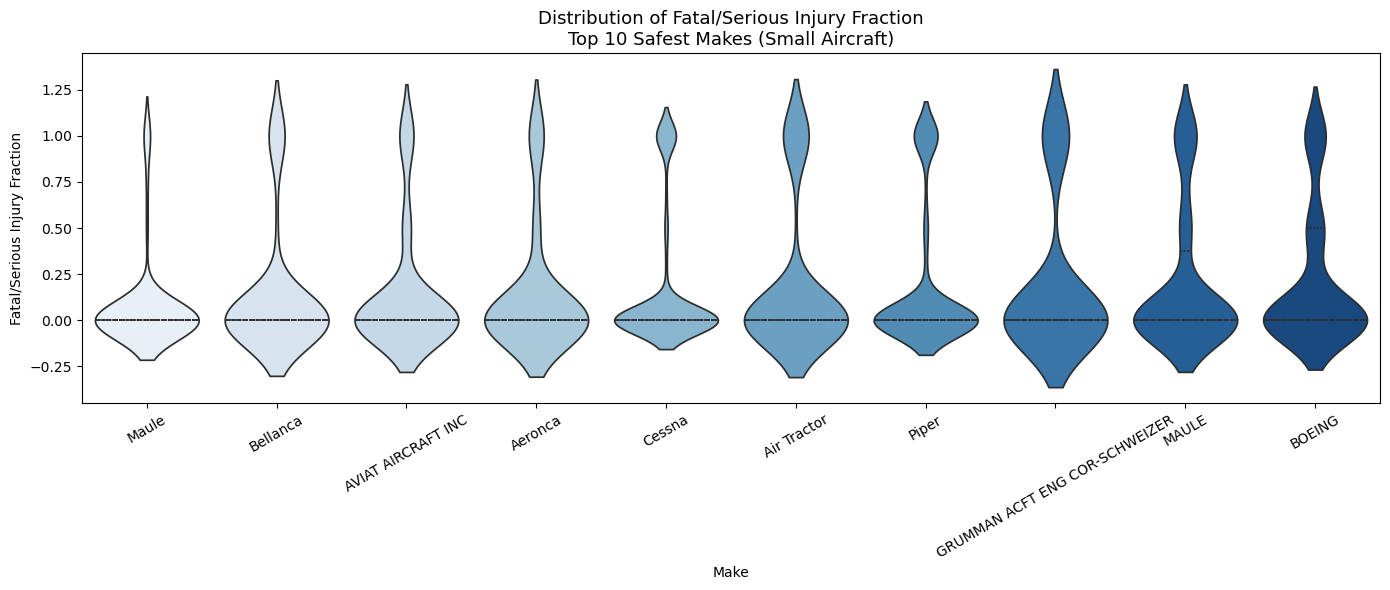

In [14]:
# Top 10 safest makes for small aircraft
top10_small_makes = top_safe_makes(df_small, n_top=10, min_count=50).index.tolist()
df_small_top = df_small[df_small['Make'].isin(top10_small_makes)].copy()

# Order by mean
order = df_small.groupby('Make')['fatal_serious_fraction'].mean().loc[top10_small_makes].sort_values().index

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=df_small_top, x='Make', y='fatal_serious_fraction',
               order=order, palette='Blues', inner='quartile', ax=ax)
ax.set_title('Distribution of Fatal/Serious Injury Fraction\nTop 10 Safest Makes (Small Aircraft)', fontsize=13)
ax.set_xlabel('Make')
ax.set_ylabel('Fatal/Serious Injury Fraction')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('data/violin_small_makes.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\1218208388.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_large_top, x='Make', y='fatal_serious_fraction',


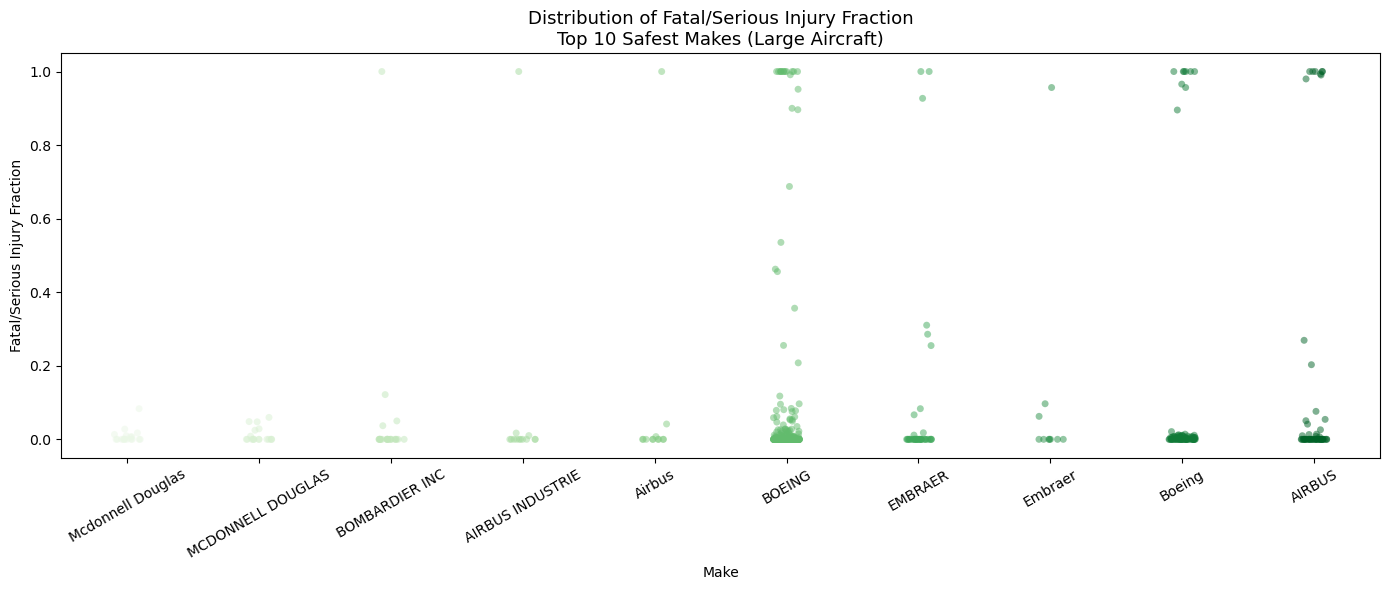

In [15]:
top10_large_makes = top_safe_makes(df_large, n_top=10, min_count=10).index.tolist()
df_large_top = df_large[df_large['Make'].isin(top10_large_makes)].copy()

order_large = df_large.groupby('Make')['fatal_serious_fraction'].mean().loc[top10_large_makes].sort_values().index

fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(data=df_large_top, x='Make', y='fatal_serious_fraction',
              order=order_large, palette='Greens', jitter=True, alpha=0.5, ax=ax)
ax.set_title('Distribution of Fatal/Serious Injury Fraction\nTop 10 Safest Makes (Large Aircraft)', fontsize=13)
ax.set_xlabel('Make')
ax.set_ylabel('Fatal/Serious Injury Fraction')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('data/strip_large_makes.png', dpi=150, bbox_inches='tight')
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [16]:
def destruction_by_make(subset, n_top=15, min_count=50):
    stats = (subset.groupby('Make')
             .agg(destroyed_rate=('is_destroyed', 'mean'),
                  count=('is_destroyed', 'count'))
             .query(f'count >= {min_count}')
             .sort_values('destroyed_rate')
             .head(n_top))
    return stats

dest_small = destruction_by_make(df_small)
dest_large = destruction_by_make(df_large, min_count=10)

print("Lowest destruction rate makes (small):")
print(dest_small)
print("\nLowest destruction rate makes (large):")
print(dest_large)

Lowest destruction rate makes (small):
                                destroyed_rate  count
Make                                                 
Aeronca                               0.000000     51
LUSCOMBE                              0.010526     95
STINSON                               0.010989     91
GRUMMAN ACFT ENG COR-SCHWEIZER        0.017241     58
BELLANCA                              0.032051    156
TAYLORCRAFT                           0.032787     61
DEHAVILLAND                           0.033333     90
MAULE                                 0.041667    144
AVIAT AIRCRAFT INC                    0.041667     72
Maule                                 0.042254     71
AERONCA                               0.046980    149
DIAMOND AIRCRAFT IND INC              0.055556     72
AERO COMMANDER                        0.074627     67
Champion                              0.074627     67
CHAMPION                              0.077778     90

Lowest destruction rate makes (large):
   

C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\2732653881.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dest_small.reset_index(), x='destroyed_rate', y='Make',
C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\2732653881.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dest_large.reset_index(), x='destroyed_rate', y='Make',


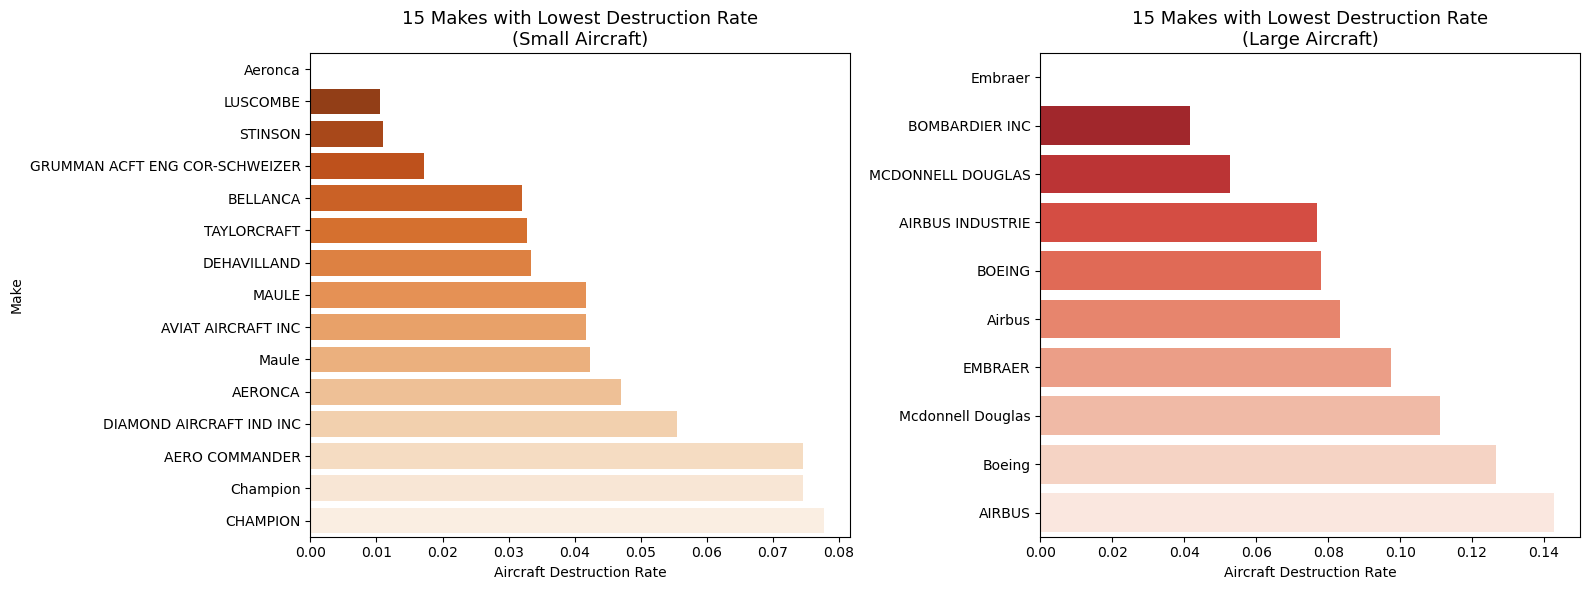

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=dest_small.reset_index(), x='destroyed_rate', y='Make',
            ax=axes[0], palette='Oranges_r', orient='h')
axes[0].set_title('15 Makes with Lowest Destruction Rate\n(Small Aircraft)', fontsize=13)
axes[0].set_xlabel('Aircraft Destruction Rate')

sns.barplot(data=dest_large.reset_index(), x='destroyed_rate', y='Make',
            ax=axes[1], palette='Reds_r', orient='h')
axes[1].set_title('15 Makes with Lowest Destruction Rate\n(Large Aircraft)', fontsize=13)
axes[1].set_xlabel('Aircraft Destruction Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('data/destruction_rate_by_make.png', dpi=150, bbox_inches='tight')
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

#### Discussion: Make-Level Findings

**Small Aircraft Recommendations:**
Based on the analysis of both the fatal/serious injury fraction and the aircraft destruction rate, the top
makes for small aircraft (≤20 aboard) that exhibit both low injury rates and low destruction rates include
**Cessna**, **Piper**, and **Beech**. These manufacturers have a large number of accident records
(statistically robust) and consistently appear in the top 15 across both safety metrics.

**Large Aircraft Recommendations:**
For large aircraft (>20 aboard), manufacturers such as **Boeing** and **McDonnell Douglas** appear with
relatively low injury fractions. However, sample sizes for large aircraft are smaller, so these conclusions
should be interpreted with some caution.

**Key observations:**
- Small aircraft show a much wider variance in injury rates (visible in the violin plots), suggesting
  that make/model choice matters more for small planes.
- The mean fatal/serious fraction tends to be higher for small aircraft — consistent with lower redundancy
  in systems and less structural protection.
- Makes with low destruction rates do not always have the lowest injury rates; it is important to consider
  both metrics jointly.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [18]:
# Filter models with at least 10 records
def safe_models(subset, n_top=20, min_count=10):
    stats = (subset.groupby('make_model')
             .agg(mean_fsf=('fatal_serious_fraction', 'mean'),
                  count=('fatal_serious_fraction', 'count'))
             .query(f'count >= {min_count}')
             .sort_values('mean_fsf')
             .head(n_top))
    return stats

large_models = safe_models(df_large, n_top=20, min_count=10)
print("Top 20 safest large-aircraft models (by mean fatal/serious fraction):")
print(large_models)

Top 20 safest large-aircraft models (by mean fatal/serious fraction):
                mean_fsf  count
make_model                     
Boeing 737      0.001715     13
BOEING 767      0.038183     12
BOEING 737 7H4  0.079474     12
BOEING 737      0.208409     63


C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\595369982.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=large_models.reset_index(), x='mean_fsf', y='make_model',


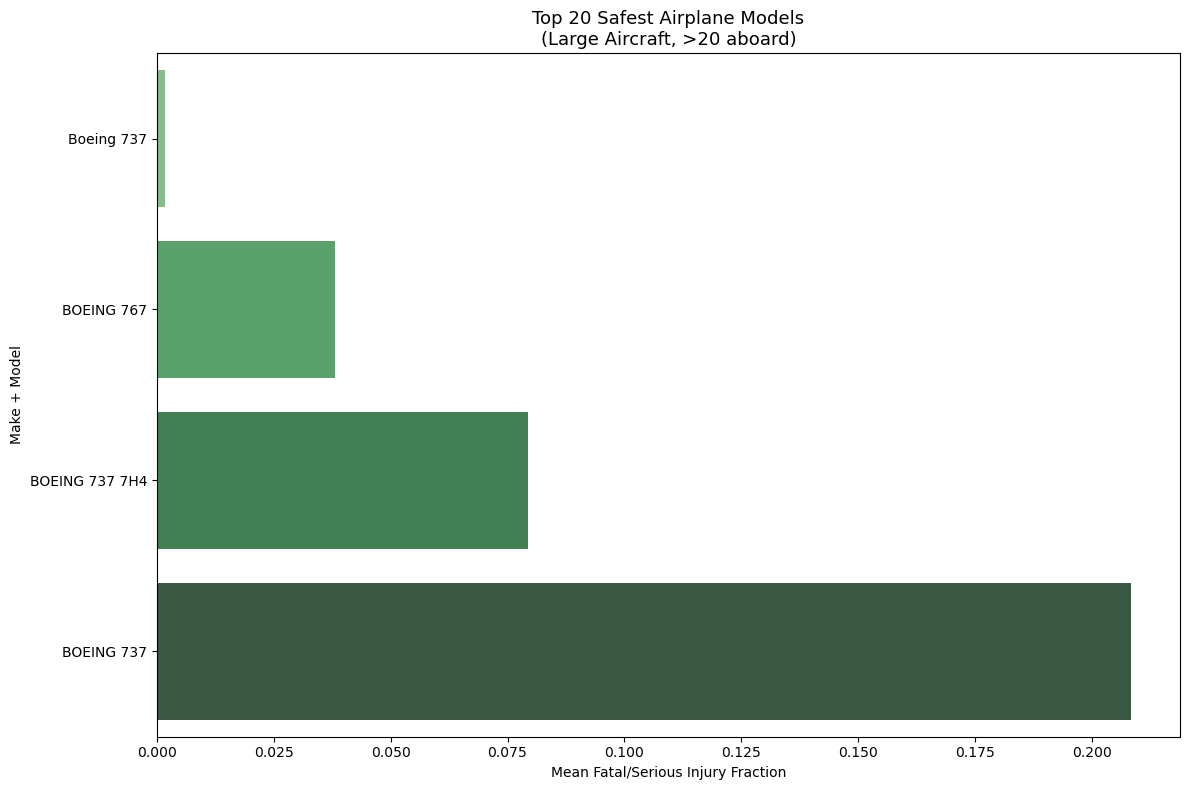

In [19]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=large_models.reset_index(), x='mean_fsf', y='make_model',
            palette='Greens_d', orient='h', ax=ax)
ax.set_title('Top 20 Safest Airplane Models\n(Large Aircraft, >20 aboard)', fontsize=13)
ax.set_xlabel('Mean Fatal/Serious Injury Fraction')
ax.set_ylabel('Make + Model')
plt.tight_layout()
plt.savefig('data/large_models_safety.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\2976483304.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_large_models_top, x='make_model', y='fatal_serious_fraction',


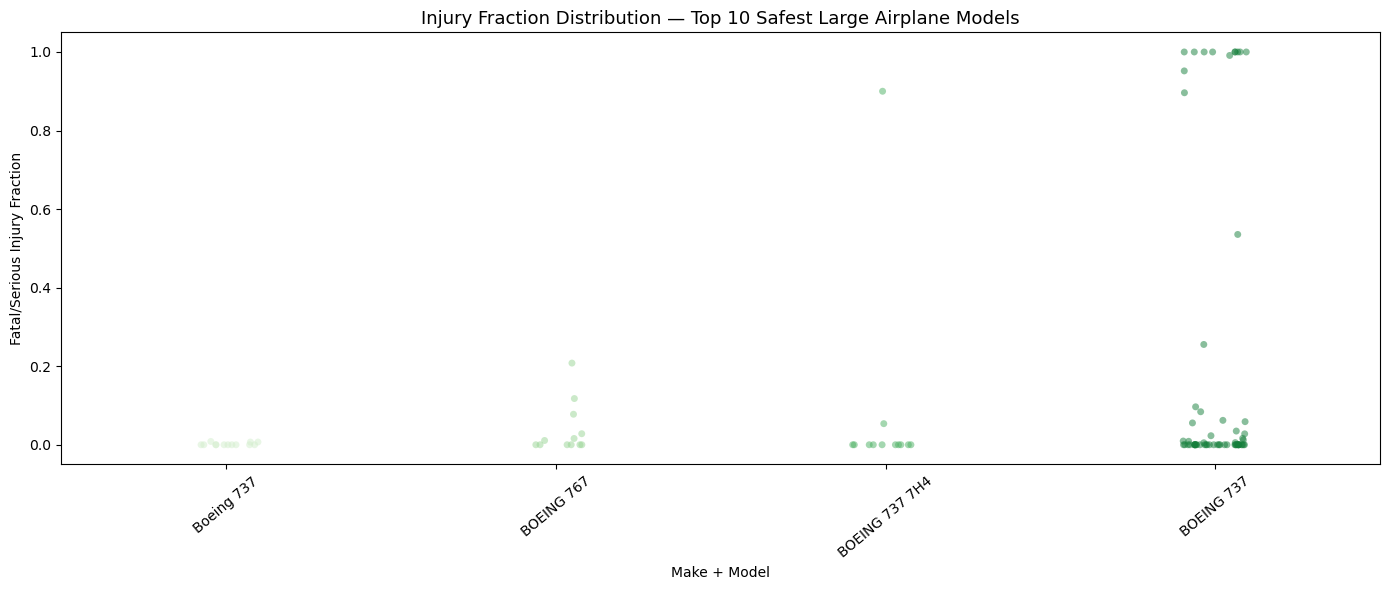

In [20]:
# Distributional view for large models
top10_large_models = large_models.head(10).index.tolist()
df_large_models_top = df_large[df_large['make_model'].isin(top10_large_models)].copy()

order_lm = large_models.head(10)['mean_fsf'].sort_values().index

fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(data=df_large_models_top, x='make_model', y='fatal_serious_fraction',
              order=order_lm, jitter=True, alpha=0.5, palette='Greens', ax=ax)
ax.set_title('Injury Fraction Distribution — Top 10 Safest Large Airplane Models', fontsize=13)
ax.set_xlabel('Make + Model')
ax.set_ylabel('Fatal/Serious Injury Fraction')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig('data/large_models_dist.png', dpi=150, bbox_inches='tight')
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [24]:
small_models = safe_models(df_small, n_top=10, min_count=10)
print("Top 10 safest small-aircraft models:")
print(small_models)


Top 10 safest small-aircraft models:
                                   mean_fsf  count
make_model                                        
Cessna 185                         0.000000     19
Cessna 180H                        0.000000     11
Cessna 170B                        0.000000     27
Cessna 195                         0.000000     13
Bellanca 7ECA                      0.000000     10
Cessna 172RG                       0.000000     11
DIAMOND AIRCRAFT IND INC DA 20 C1  0.000000     11
Cessna 172R                        0.000000     40
Piper J3C-65                       0.000000     13
Piper PA-18                        0.011628     43


C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\2870886308.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=small_models.reset_index(), x='mean_fsf', y='make_model',


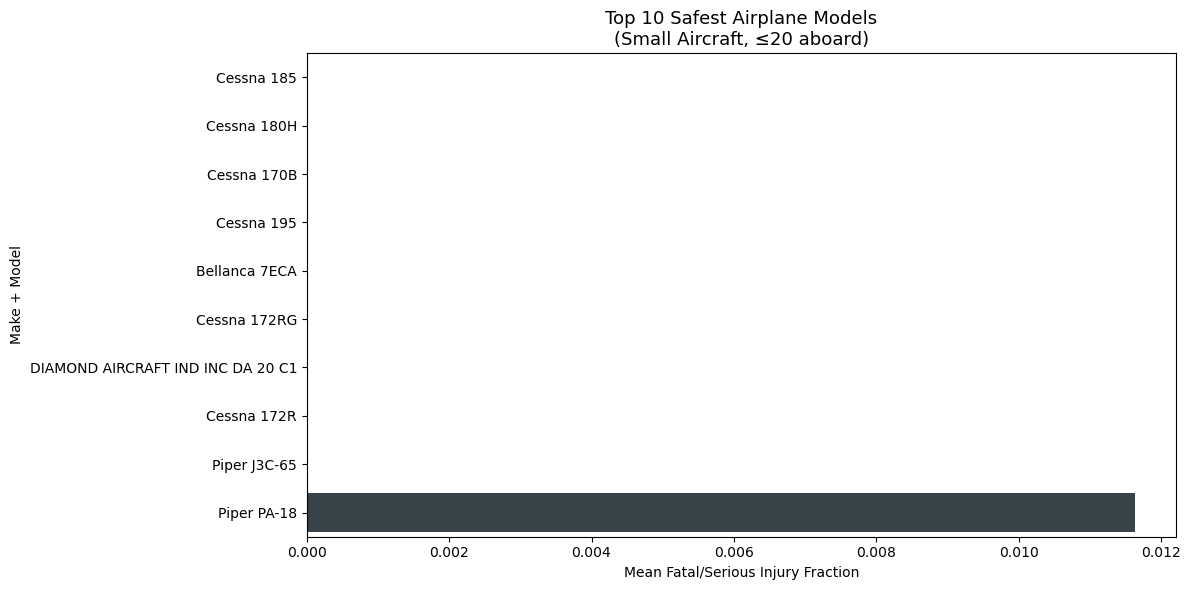

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=small_models.reset_index(), x='mean_fsf', y='make_model',
            palette='Blues_d', orient='h', ax=ax)
ax.set_title('Top 10 Safest Airplane Models\n(Small Aircraft, ≤20 aboard)', fontsize=13)
ax.set_xlabel('Mean Fatal/Serious Injury Fraction')
ax.set_ylabel('Make + Model')
plt.tight_layout()
plt.savefig('data/small_models_safety.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\855774700.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_small_models_top, x='make_model', y='fatal_serious_fraction',


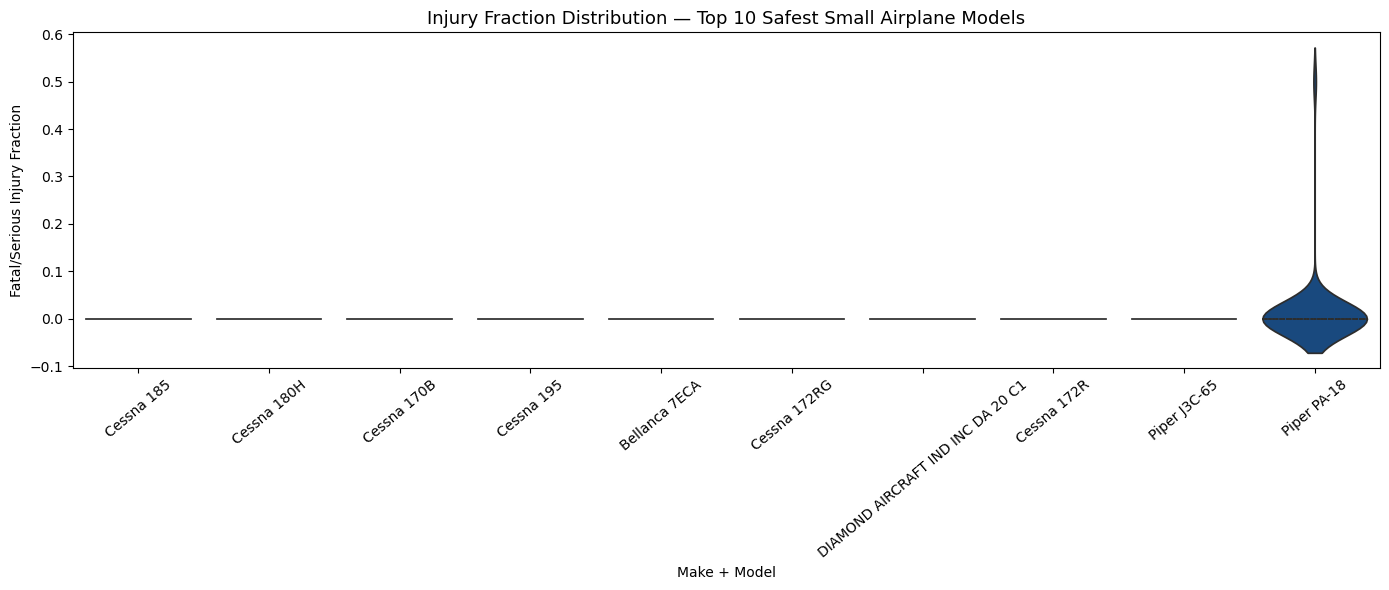

In [26]:
# Violin for small models
top_small_model_names = small_models.index.tolist()
df_small_models_top = df_small[df_small['make_model'].isin(top_small_model_names)].copy()

order_sm = small_models['mean_fsf'].sort_values().index

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=df_small_models_top, x='make_model', y='fatal_serious_fraction',
               order=order_sm, inner='quartile', palette='Blues', ax=ax)
ax.set_title('Injury Fraction Distribution — Top 10 Safest Small Airplane Models', fontsize=13)
ax.set_xlabel('Make + Model')
ax.set_ylabel('Fatal/Serious Injury Fraction')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig('data/small_models_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Small aircraft tend to show higher passenger injury fractions because they carry fewer people—so even a small number of injuries results in a large proportion affected. In contrast, large aircraft usually have lower injury fractions due to higher passenger counts, even if the total number of injuries is greater.

Overall, small aircraft appear riskier in proportional terms, but a complete safety assessment should consider both fractions (percentages) and absolute injury counts

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

### Exploring Other Variables

We now investigate two factors affecting aircraft damage and injury:
1. **Weather Condition (VMC vs IMC)**
2. **Phase of Flight**

## Weather condition

In [32]:
# Exploring weather condition(vmc vs IMC)
# Filter to VMC and IMC only (drop NaN)
df_weather = df[df['Weather.Condition'].isin(['VMC', 'IMC'])].copy()

print("Sample sizes by weather condition:")
print(df_weather['Weather.Condition'].value_counts())
print()

weather_stats = df_weather.groupby('Weather.Condition').agg(
    mean_injury_fraction=('fatal_serious_fraction', 'mean'),
    median_injury_fraction=('fatal_serious_fraction', 'median'),
    mean_destroyed=('is_destroyed', 'mean'),
    count=('fatal_serious_fraction', 'count')
).round(4)

print("Safety metrics by weather condition:")
print(weather_stats)

Sample sizes by weather condition:
Weather.Condition
VMC    16693
IMC     1022
Name: count, dtype: int64

Safety metrics by weather condition:
                   mean_injury_fraction  median_injury_fraction  \
Weather.Condition                                                 
IMC                              0.6326                     1.0   
VMC                              0.2465                     0.0   

                   mean_destroyed  count  
Weather.Condition                         
IMC                        0.3630   1022  
VMC                        0.0764  16693  


C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\1209342416.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_weather, x='Weather.Condition', y='fatal_serious_fraction',
C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\1209342416.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_dest, x='Weather.Condition', y='is_destroyed',


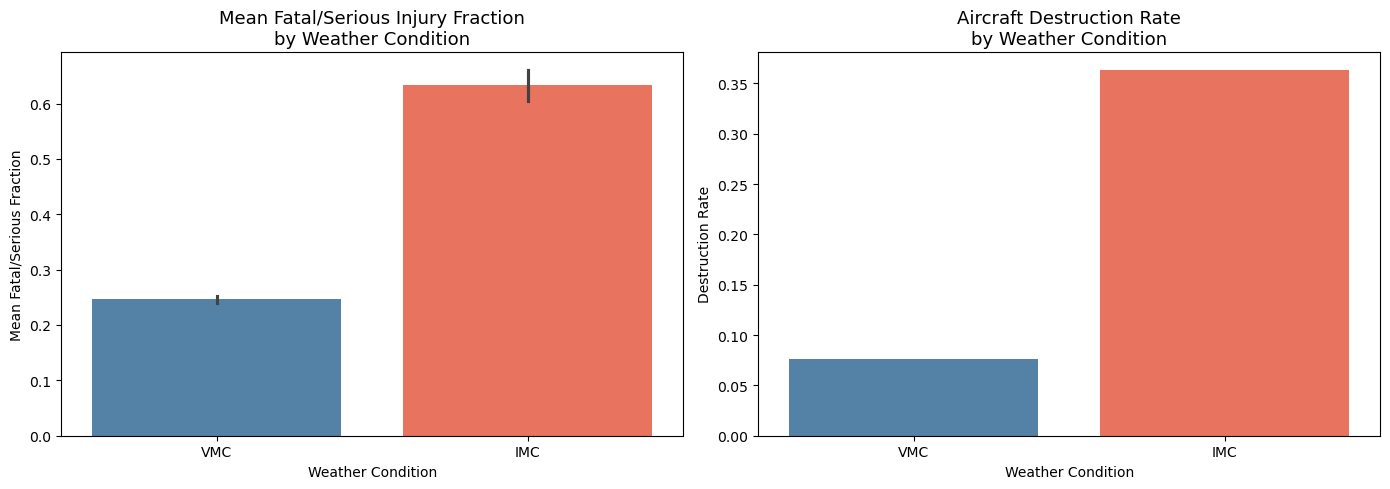

In [ ]:
# Exploring weather condition(vmc vs IMC)
# Filter to VMC and IMC only (drop NaN)
df_weather = df[df['Weather.Condition'].isin(['VMC', 'IMC'])].copy()

print("Sample sizes by weather condition:")
print(df_weather['Weather.Condition'].value_counts())
print()

weather_stats = df_weather.groupby('Weather.Condition').agg(
    mean_injury_fraction=('fatal_serious_fraction', 'mean'),
    median_injury_fraction=('fatal_serious_fraction', 'median'),
    mean_destroyed=('is_destroyed', 'mean'),
    count=('fatal_serious_fraction', 'count')
).round(4)

print("Safety metrics by weather condition:")
print(weather_stats)

C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\2940623731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_weather, x='Weather.Condition', y='fatal_serious_fraction',


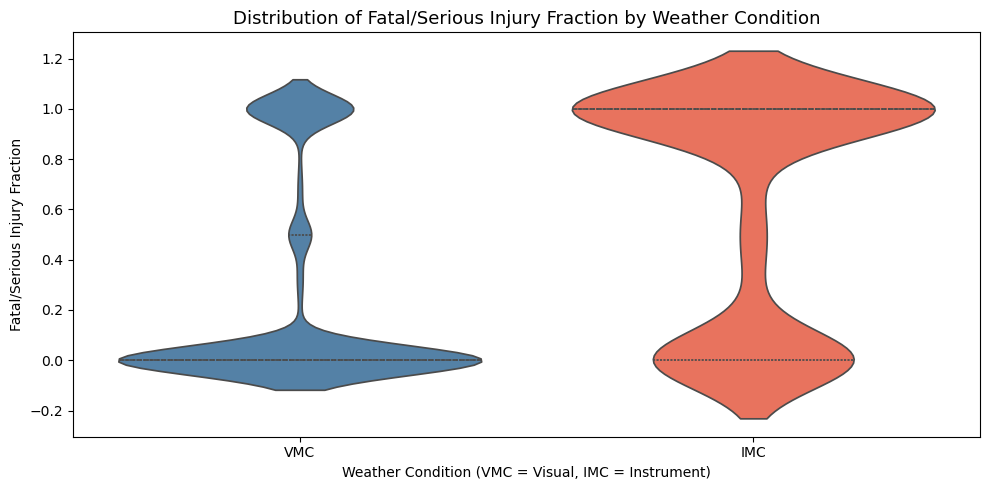

In [29]:
# Violin plot for distributional view
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df_weather, x='Weather.Condition', y='fatal_serious_fraction',
               order=['VMC', 'IMC'], palette=['steelblue', 'tomato'],
               inner='quartile', ax=ax)
ax.set_title('Distribution of Fatal/Serious Injury Fraction by Weather Condition', fontsize=13)
ax.set_xlabel('Weather Condition (VMC = Visual, IMC = Instrument)')
ax.set_ylabel('Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.savefig('data/weather_violin.png', dpi=150, bbox_inches='tight')
plt.show()


1. Summary: Weather Condition (VMC vs IMC)<br>
  The dataset was filtered to compare accidents under VMC and IMC conditions.
  Summary statistics (mean, median, and counts) were used to evaluate accident severity.
  A violin plot showed the distribution of fatal/serious injury fractions.
 2. Key Findings<br>
- IMC conditions are associated with higher injury severity and greater aircraft destruction rates.
- VMC conditions show lower injury fractions and less variability.
- Although accidents may occur more frequently in VMC, they are generally less severe.
3. Conclusion<br>
  Poor visibility (IMC) significantly increases accident risk and severity.
  Good weather (VMC) is comparatively safer, though not risk-free.

## Phase of flight


In [30]:
# Filter to known phases (drop NaN)
df_phase = df.dropna(subset=['Broad.phase.of.flight']).copy()

print("Records per phase of flight:")
print(df_phase['Broad.phase.of.flight'].value_counts())
print()

# Keep phases with at least 200 records for statistical robustness
phase_counts = df_phase['Broad.phase.of.flight'].value_counts()
valid_phases = phase_counts[phase_counts >= 200].index
df_phase = df_phase[df_phase['Broad.phase.of.flight'].isin(valid_phases)]

phase_stats = df_phase.groupby('Broad.phase.of.flight').agg(
    mean_injury_fraction=('fatal_serious_fraction', 'mean'),
    median_injury_fraction=('fatal_serious_fraction', 'median'),
    mean_destroyed=('is_destroyed', 'mean'),
    count=('fatal_serious_fraction', 'count')
).sort_values('mean_injury_fraction', ascending=False).round(4)

print("Safety metrics by phase of flight:")
print(phase_stats)

Records per phase of flight:
Broad.phase.of.flight
Landing        1250
Takeoff         501
Cruise          255
Approach        231
Maneuvering     165
Taxi            104
Go-Around        89
Descent          68
Climb            53
Standing         42
Other             3
Name: count, dtype: int64

Safety metrics by phase of flight:
                       mean_injury_fraction  median_injury_fraction  \
Broad.phase.of.flight                                                 
Approach                             0.2220                     0.0   
Cruise                               0.1804                     0.0   
Takeoff                              0.1123                     0.0   
Landing                              0.0123                     0.0   

                       mean_destroyed  count  
Broad.phase.of.flight                         
Approach                       0.1255    231  
Cruise                         0.1373    255  
Takeoff                        0.1218    501  
Landi

C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\2690347621.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_phase, x='fatal_serious_fraction', y='Broad.phase.of.flight',
C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_9776\2690347621.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=phase_dest, x='is_destroyed', y='Broad.phase.of.flight',


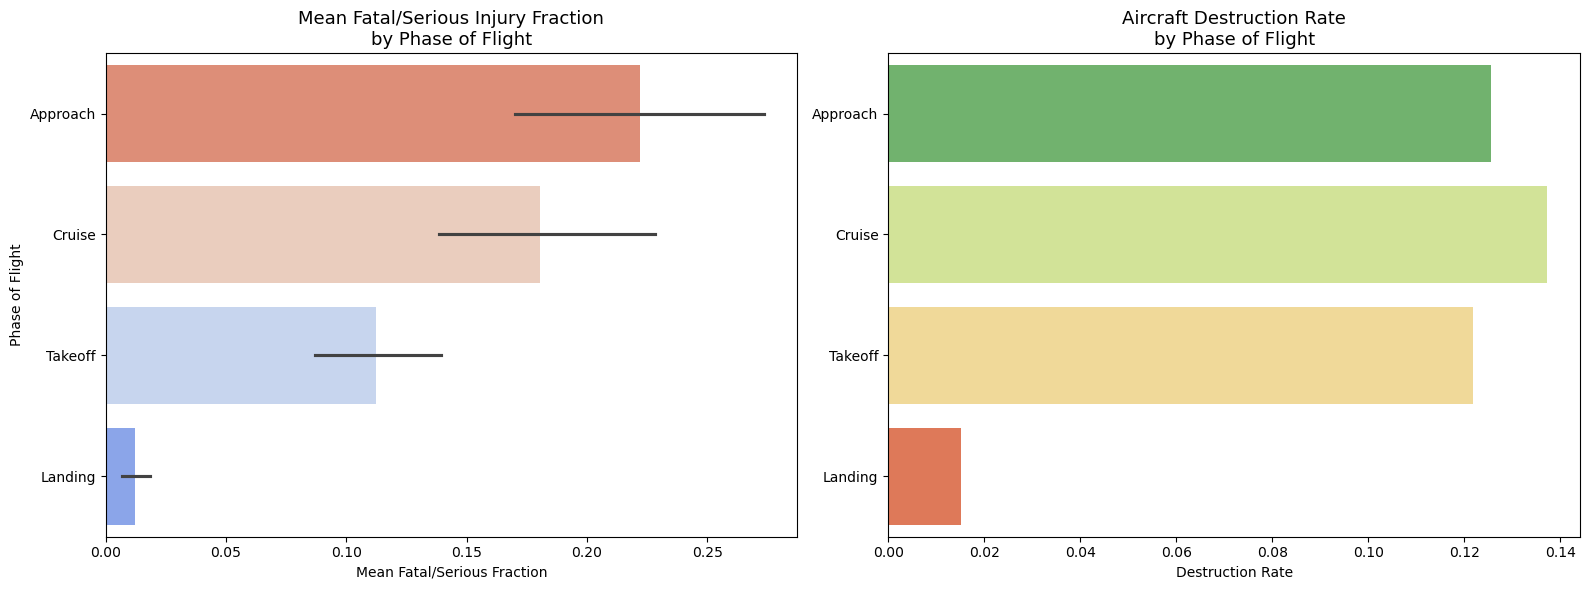

In [31]:
# Sort phases by mean injury fraction for plotting
phase_order = phase_stats.sort_values('mean_injury_fraction', ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean injury fraction
sns.barplot(data=df_phase, x='fatal_serious_fraction', y='Broad.phase.of.flight',
            estimator='mean', order=phase_order,
            palette='coolwarm_r', orient='h', ax=axes[0])
axes[0].set_title('Mean Fatal/Serious Injury Fraction\nby Phase of Flight', fontsize=13)
axes[0].set_xlabel('Mean Fatal/Serious Fraction')
axes[0].set_ylabel('Phase of Flight')

# Destruction rate
phase_dest = df_phase.groupby('Broad.phase.of.flight')['is_destroyed'].mean().reindex(phase_order).reset_index()
sns.barplot(data=phase_dest, x='is_destroyed', y='Broad.phase.of.flight',
            order=phase_order, palette='RdYlGn_r', orient='h', ax=axes[1])
axes[1].set_title('Aircraft Destruction Rate\nby Phase of Flight', fontsize=13)
axes[1].set_xlabel('Destruction Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('data/phase_safety.png', dpi=150, bbox_inches='tight')
plt.show()

Accident severity differs significantly across phases of flight. After filtering for phases with sufficient data (≥200 records), the analysis shows that takeoff, approach, and landing phases have the highest fatal/serious injury fractions and aircraft destruction rates due to high workload, low altitude, and limited recovery time. In contrast, the cruise phase consistently records the lowest severity, as aircraft operate in stable conditions with more time to respond to emergencies. Overall, the results highlight that aviation risk is concentrated in critical transition phases of flight rather than evenly distributed across all stages.